1. Generazione Traiettoria Vera in corso...
2. Simulazione fix GNSS (SPP - Single Point Positioning)...
3. Inizializzazione Filtro di Kalman (OBC)...
4. Filtraggio EKF in corso...

VERIFICA NUMERICA: Spiegazione dei dati e degli errori nei primi 3 istanti

--- [Tempo di volo: 0.0 secondi] ---
  [Posizione X]   Verità:   7071058.86 m | GNSS (SPP):   7071063.83 m | EKF:   7071063.93 m
    -> Errore calcolato | SPP (Misura - Verità):   +4.97 m | EKF (Stima - Verità):   +5.07 m
  [Velocità Vx]   Verità:       0.0000 m/s | GNSS (SPP):       0.1523 m/s | EKF:       0.1533 m/s
    -> Errore calcolato | SPP (Misura - Verità): +0.1523 m/s | EKF (Stima - Verità): +0.1533 m/s

--- [Tempo di volo: 10.0 secondi] ---
  [Posizione X]   Verità:   7070659.73 m | GNSS (SPP):   7070675.53 m | EKF:   7070670.82 m
    -> Errore calcolato | SPP (Misura - Verità):  +15.79 m | EKF (Stima - Verità):  +11.08 m
  [Velocità Vx]   Verità:     -79.8250 m/s | GNSS (SPP):     -79.7707 m/s | EKF:     -79.7211 m/s
    

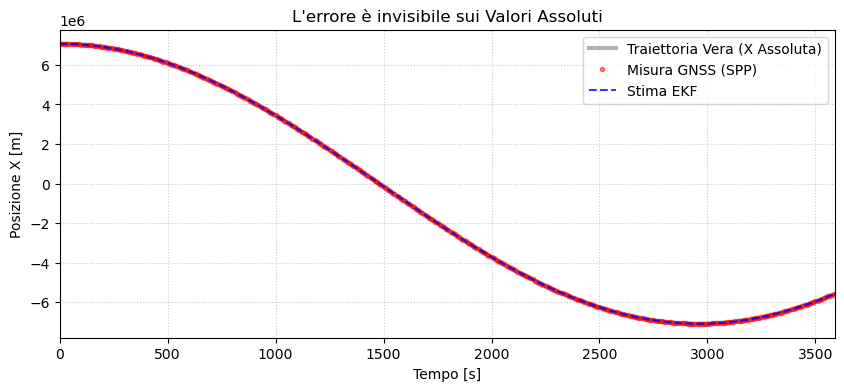

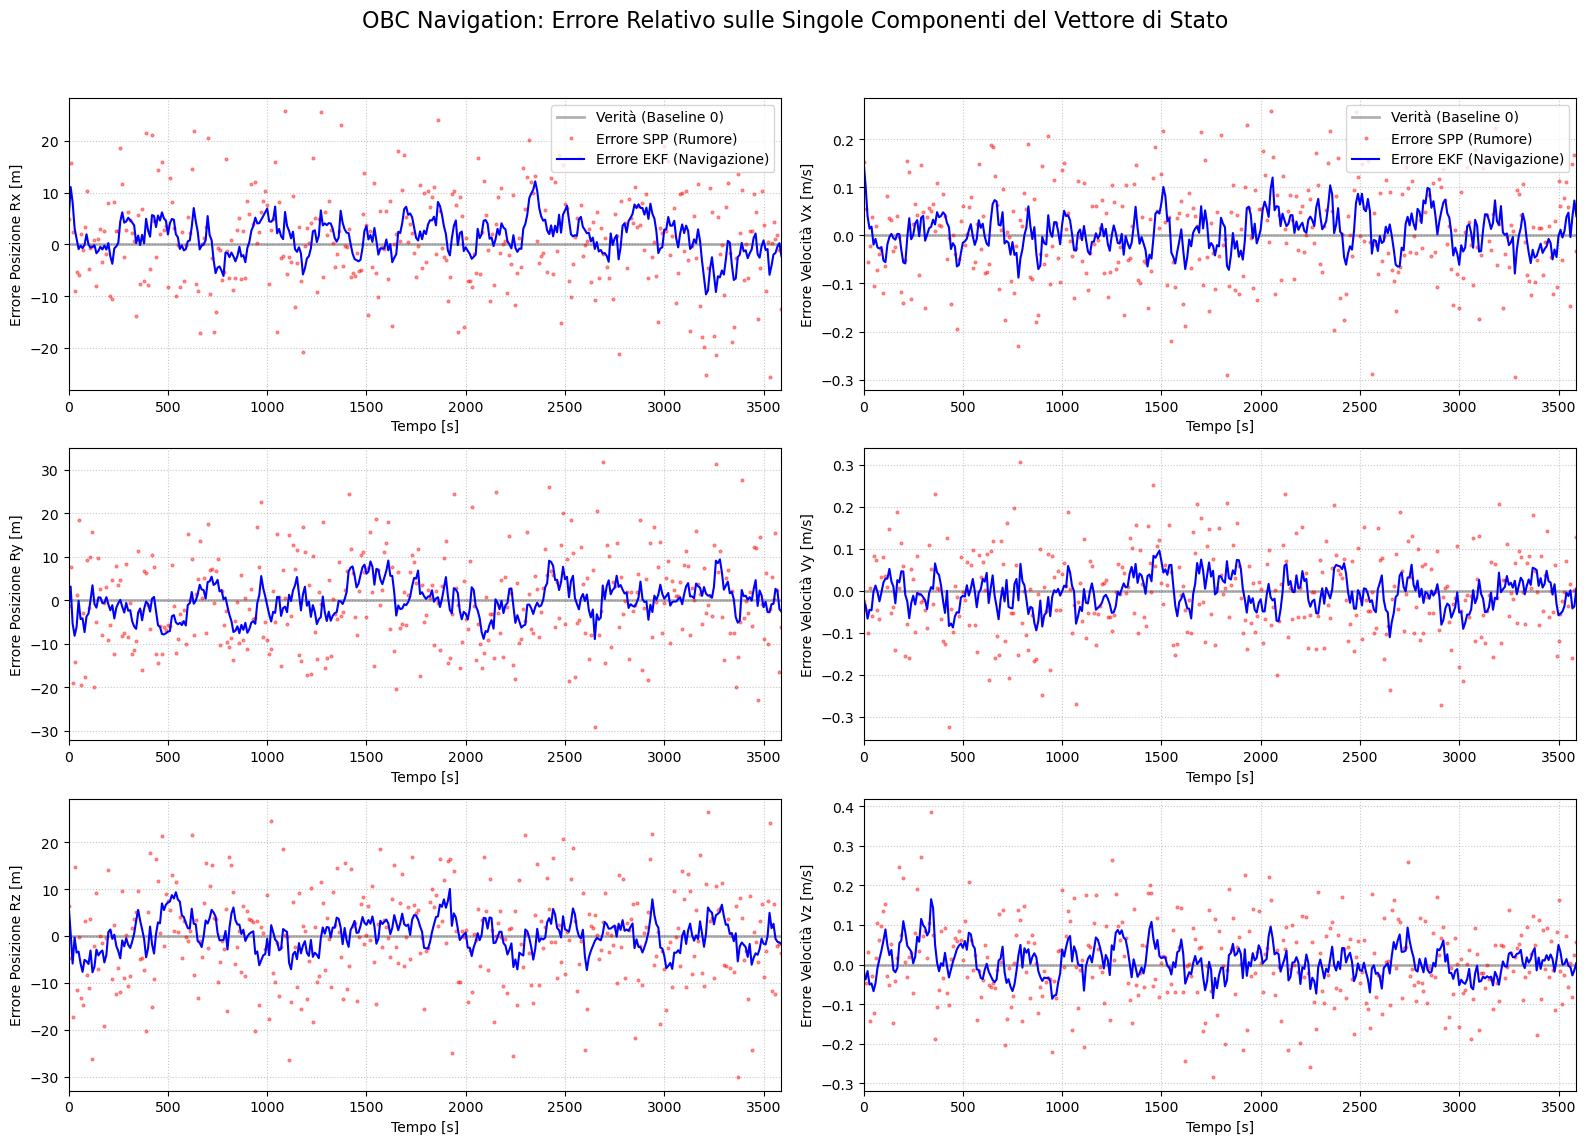

In [21]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double

# =========================================================================
# INIZIALIZZAZIONE JAVA E OREKIT
# =========================================================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, CartesianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions, PVCoordinates
from org.hipparchus.geometry.euclidean.threed import Vector3D
from org.orekit.propagation.numerical import NumericalPropagator
from org.orekit.propagation.conversion import NumericalPropagatorBuilder, ClassicalRungeKuttaIntegratorBuilder
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction
from org.orekit.estimation.measurements import PV, ObservableSatellite
from org.orekit.estimation.sequential import KalmanEstimatorBuilder, ConstantProcessNoise
from org.hipparchus.linear import MatrixUtils
from org.orekit.forces.drag import DragForce, IsotropicDrag
from org.orekit.models.earth.atmosphere import HarrisPriester
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient
from org.orekit.bodies import CelestialBodyFactory, OneAxisEllipsoid

# =========================================================================
# FASE 1: GENERAZIONE DELLA "TRUTH TRAJECTORY" 
# =========================================================================
print("1. Generazione Traiettoria Vera in corso...")
utc = TimeScalesFactory.getUTC()
epoch = AbsoluteDate(2026, 8, 24, 12, 0, 0.0, utc)
inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
mu = Constants.WGS84_EARTH_MU

# Orbita LEO a 700 km di quota
a = Constants.WGS84_EARTH_EQUATORIAL_RADIUS + 700000.0
ecc = 0.001
inc = math.radians(98.0)
truth_orbit = KeplerianOrbit(a, ecc, inc, 0.0, 0.0, 0.0, PositionAngleType.MEAN, inertial_frame, epoch, mu)

# Propagatore di riferimento ad alta precisione (DP853)
min_step = 0.001
max_step = 300.0
tolerances = NumericalPropagator.tolerances(1.0, truth_orbit, truth_orbit.getType())
abs_tolerance = JArray_double.cast_(tolerances[0])
rel_tolerance = JArray_double.cast_(tolerances[1])

truth_integrator = DormandPrince853Integrator(min_step, max_step, abs_tolerance, rel_tolerance)
truth_propagator = NumericalPropagator(truth_integrator)
truth_propagator.setInitialState(SpacecraftState(truth_orbit))

# Modelli di forza perturbativi ad alta fedeltà
earth_shape = OneAxisEllipsoid(Constants.WGS84_EARTH_EQUATORIAL_RADIUS, Constants.WGS84_EARTH_FLATTENING, earth_frame)
sun = CelestialBodyFactory.getSun()
moon = CelestialBodyFactory.getMoon()
truth_propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, GravityFieldFactory.getNormalizedProvider(20, 20)))
truth_propagator.addForceModel(ThirdBodyAttraction(sun))
truth_propagator.addForceModel(ThirdBodyAttraction(moon))
truth_propagator.addForceModel(SolarRadiationPressure(sun, earth_shape, IsotropicRadiationSingleCoefficient(2.5, 1.2)))
truth_propagator.addForceModel(DragForce(HarrisPriester(sun, earth_shape), IsotropicDrag(2.5, 2.2)))

# Creazione effemeridi di riferimento (1 ora di volo)
ephemeris_generator = truth_propagator.getEphemerisGenerator()
truth_propagator.propagate(epoch.shiftedBy(3600.0))
truth_ephemeris = ephemeris_generator.getGeneratedEphemeris()

# =========================================================================
# FASE 2: SIMULAZIONE DEL SENSORE GNSS (Modellazione Black-Box a livello SPP / PVT)
# =========================================================================
print("2. Simulazione misura GNSS a livello PVT (SPP-like)...")
# NOTA DI DESIGN:
# In questo progetto non viene implementato il processamento GNSS a partire
# dalle osservazioni dei satelliti (pseudorange, effemeridi, clock, ecc.).
# Il ricevitore GNSS è quindi modellato come una black-box che fornisce
# direttamente una soluzione PVT (Position, Velocity, Time).
#
# La misura PVT viene generata perturbando la traiettoria truth con rumore
# gaussiano bianco, assumendo un'accuratezza rappresentativa di una soluzione
# GNSS SPP: sigma_pos = 10 m e sigma_vel = 0.1 m/s.
#
# La simulazione utilizza un riferimento temporale comune e coerente
# (AbsoluteDate/UTC) per truth, propagazione e misure. Si assume quindi
# implicitamente una sincronizzazione temporale ideale, senza modellare
# esplicitamente offset e drift degli orologi del ricevitore e dei satelliti.
#
# Questa scelta consente di concentrarsi sull'integrazione della sorgente
# GNSS nel sistema di navigazione orbitale OBC e sulla fusione della misura
# con il modello dinamico mediante EKF, senza simulare esplicitamente
# costellazione, pseudorange, carrier phase e relativi errori di propagazione.

step_gnss = 10.0
times = np.arange(0, 3600.0, step_gnss)

sigma_pos = 10.0  # Errore standard 1-sigma posizione [m] (Tipico SPP)
sigma_vel = 0.1   # Errore standard 1-sigma velocità [m/s]
measurements = []
obs_sat = ObservableSatellite(0)

np.random.seed(42)
truth_states = []

for t in times:
    current_date = epoch.shiftedBy(float(t))
    true_state = truth_ephemeris.propagate(current_date)
    true_pv = true_state.getPVCoordinates()
    
    # Salvataggio dello stato vero (Truth)
    truth_states.append({
        'pos': [true_pv.getPosition().getX(), true_pv.getPosition().getY(), true_pv.getPosition().getZ()],
        'vel': [true_pv.getVelocity().getX(), true_pv.getVelocity().getY(), true_pv.getVelocity().getZ()]
    })
    
   # Iniezione di rumore bianco gaussiano sulla truth per simulare una misura PVT con accuratezza rappresentativa di una soluzione SPP.
    noisy_pos = Vector3D(float(truth_states[-1]['pos'][0] + np.random.normal(0, sigma_pos)),
                         float(truth_states[-1]['pos'][1] + np.random.normal(0, sigma_pos)),
                         float(truth_states[-1]['pos'][2] + np.random.normal(0, sigma_pos)))
    
    noisy_vel = Vector3D(float(truth_states[-1]['vel'][0] + np.random.normal(0, sigma_vel)),
                         float(truth_states[-1]['vel'][1] + np.random.normal(0, sigma_vel)),
                         float(truth_states[-1]['vel'][2] + np.random.normal(0, sigma_vel)))
    
    # Creazione della misura PV temporizzata (orologio sincronizzato)
    meas = PV(current_date, noisy_pos, noisy_vel, float(sigma_pos), float(sigma_vel), 1.0, obs_sat)
    measurements.append(meas)

# =========================================================================
# FASE 3: SETUP DELL'EXTENDED KALMAN FILTER (OBC)
# =========================================================================
print("3. Inizializzazione Filtro di Kalman (OBC)...")
obc_step = 10.0
obc_integrator_builder = ClassicalRungeKuttaIntegratorBuilder(obc_step)

# Guess iniziale sballato di 1 km e 10 m/s
true_initial_pv = truth_orbit.getPVCoordinates()
guess_pos = Vector3D(float(true_initial_pv.getPosition().getX() + 1000.0),
                     float(true_initial_pv.getPosition().getY() + 1000.0),
                     float(true_initial_pv.getPosition().getZ() + 1000.0))
guess_vel = Vector3D(float(true_initial_pv.getVelocity().getX() + 10.0),
                     float(true_initial_pv.getVelocity().getY() - 10.0),
                     float(true_initial_pv.getVelocity().getZ() + 10.0))

initial_guess_orbit = CartesianOrbit(PVCoordinates(guess_pos, guess_vel), inertial_frame, epoch, mu)
propagator_builder = NumericalPropagatorBuilder(initial_guess_orbit, obc_integrator_builder, PositionAngleType.MEAN, 1.0)
propagator_builder.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, GravityFieldFactory.getNormalizedProvider(10, 10)))

# Matrice di covarianza iniziale P0 (incertezza iniziale dell'OBC)
cov_init = MatrixUtils.createRealMatrix(6, 6)
for i in range(3):
    cov_init.setEntry(i, i, 1000.0**2)
    cov_init.setEntry(i+3, i+3, 10.0**2)

# Matrice di rumore di processo Q (incertezza del modello semplificato dell'OBC)
cov_process = MatrixUtils.createRealMatrix(6, 6)
for i in range(3):
    cov_process.setEntry(i, i, 5.0)        
    cov_process.setEntry(i+3, i+3, 1e-3)   

kalman_builder = KalmanEstimatorBuilder()
kalman_builder.addPropagationConfiguration(propagator_builder, ConstantProcessNoise(cov_init, cov_process))
estimator = kalman_builder.build()

# =========================================================================
# FASE 4: ELABORAZIONE E VERIFICA NUMERICA IN CONSOLE
# =========================================================================
print("4. Filtraggio EKF in corso...\n")
estimated_states = []

for meas in measurements:
    # Esegue Predict (modello OBC) + Update (fusione con misura SPP)
    corrected_propagators = estimator.estimationStep(meas)
    est_state = corrected_propagators[0].getInitialState()
    est_pv = est_state.getPVCoordinates()
    
    estimated_states.append({
        'pos': [est_pv.getPosition().getX(), est_pv.getPosition().getY(), est_pv.getPosition().getZ()],
        'vel': [est_pv.getVelocity().getX(), est_pv.getVelocity().getY(), est_pv.getVelocity().getZ()]
    })

# Stampa di verifica numerica dettagliata
print("=" * 90)
print("VERIFICA NUMERICA: Spiegazione dei dati e degli errori nei primi 3 istanti")
print("=" * 90)
for i in range(3):
    print(f"\n--- [Tempo di volo: {times[i]:.1f} secondi] ---")
    
    t_px = truth_states[i]['pos'][0]
    m_px = measurements[i].getPosition().getX()
    e_px = estimated_states[i]['pos'][0]
    print(f"  [Posizione X]   Verità: {t_px:12.2f} m | GNSS (SPP): {m_px:12.2f} m | EKF: {e_px:12.2f} m")
    print(f"    -> Errore calcolato | SPP (Misura - Verità): {m_px - t_px:+7.2f} m | EKF (Stima - Verità): {e_px - t_px:+7.2f} m")
    
    t_vx = truth_states[i]['vel'][0]
    m_vx = measurements[i].getVelocity().getX()
    e_vx = estimated_states[i]['vel'][0]
    print(f"  [Velocità Vx]   Verità: {t_vx:12.4f} m/s | GNSS (SPP): {m_vx:12.4f} m/s | EKF: {e_vx:12.4f} m/s")
    print(f"    -> Errore calcolato | SPP (Misura - Verità): {m_vx - t_vx:+7.4f} m/s | EKF (Stima - Verità): {e_vx - t_vx:+7.4f} m/s")
print("=" * 90 + "\n")

# =========================================================================
# FASE 5: CALCOLO DEI RESIDUI (Normalizzazione a Zero)
# =========================================================================
t_pos_x = [s['pos'][0] for s in truth_states]
m_pos_x = [m.getPosition().getX() for m in measurements]
e_pos_x = [s['pos'][0] for s in estimated_states]

err_gnss_rx = [m - t for m, t in zip(m_pos_x, t_pos_x)]
err_ekf_rx  = [e - t for e, t in zip(e_pos_x, t_pos_x)]
err_gnss_ry = [m.getPosition().getY() - s['pos'][1] for m, s in zip(measurements, truth_states)]
err_ekf_ry  = [e['pos'][1] - s['pos'][1] for e, s in zip(estimated_states, truth_states)]
err_gnss_rz = [m.getPosition().getZ() - s['pos'][2] for m, s in zip(measurements, truth_states)]
err_ekf_rz  = [e['pos'][2] - s['pos'][2] for e, s in zip(estimated_states, truth_states)]

err_gnss_vx = [m.getVelocity().getX() - s['vel'][0] for m, s in zip(measurements, truth_states)]
err_ekf_vx  = [e['vel'][0] - s['vel'][0] for e, s in zip(estimated_states, truth_states)]
err_gnss_vy = [m.getVelocity().getY() - s['vel'][1] for m, s in zip(measurements, truth_states)]
err_ekf_vy  = [e['vel'][1] - s['vel'][1] for e, s in zip(estimated_states, truth_states)]
err_gnss_vz = [m.getVelocity().getZ() - s['vel'][2] for m, s in zip(measurements, truth_states)]
err_ekf_vz  = [e['vel'][2] - s['vel'][2] for e, s in zip(estimated_states, truth_states)]

# =========================================================================
# FASE 6: VISUALIZZAZIONE GRAFICA 
# =========================================================================

# Figura 1: Valori Assoluti
fig_abs, ax_abs = plt.subplots(figsize=(10, 4))
ax_abs.plot(times, t_pos_x, 'k-', linewidth=3, alpha=0.3, label='Traiettoria Vera (X Assoluta)')
ax_abs.plot(times, m_pos_x, 'r.', alpha=0.5, label='Misura GNSS (SPP)')
ax_abs.plot(times, e_pos_x, 'b--', linewidth=1.5, alpha=0.8, label='Stima EKF')
ax_abs.set_title("L'errore è invisibile sui Valori Assoluti")
ax_abs.set_ylabel("Posizione X [m]")
ax_abs.set_xlabel("Tempo [s]")
ax_abs.set_xlim(0, max(times))
ax_abs.legend()
ax_abs.grid(True, linestyle=':', alpha=0.7)

# Figura 2: Analisi Errori Componenti 
fig_comp, axs = plt.subplots(3, 2, figsize=(16, 12), sharex=False) 
fig_comp.suptitle("OBC Navigation: Errore Relativo sulle Singole Componenti del Vettore di Stato", fontsize=16)

def plot_subplot(ax, times, err_gnss, err_ekf, ylabel, is_legend=False):
    ax.axhline(0, color='black', alpha=0.3, linewidth=2, label='Verità (Baseline 0)')
    ax.plot(times, err_gnss, 'r.', alpha=0.4, markersize=4, label='Errore SPP (Rumore)')
    ax.plot(times, err_ekf, 'b-', linewidth=1.5, label='Errore EKF (Navigazione)')
    
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Tempo [s]") 
    ax.set_xlim(0, max(times))
    ax.grid(True, linestyle=':', alpha=0.7)
    if is_legend:
        ax.legend(loc='upper right')

# Posizione [m]
plot_subplot(axs[0, 0], times, err_gnss_rx, err_ekf_rx, "Errore Posizione Rx [m]", is_legend=True)
plot_subplot(axs[1, 0], times, err_gnss_ry, err_ekf_ry, "Errore Posizione Ry [m]")
plot_subplot(axs[2, 0], times, err_gnss_rz, err_ekf_rz, "Errore Posizione Rz [m]")

# Velocità [m/s]
plot_subplot(axs[0, 1], times, err_gnss_vx, err_ekf_vx, "Errore Velocità Vx [m/s]", is_legend=True)
plot_subplot(axs[1, 1], times, err_gnss_vy, err_ekf_vy, "Errore Velocità Vy [m/s]")
plot_subplot(axs[2, 1], times, err_gnss_vz, err_ekf_vz, "Errore Velocità Vz [m/s]")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()